Tek bir nöronun ileri yayılımı (forward pass):

    Yapay bir nörün aslında basit bir doğrusal dönüşüm ve ardından gelen bir aktivasyon kodundan ibarettir. 
    Girdi değeri (x) ve her bir girdi değerinin ne kadar önemli olduğunu belirleyen ağırlıklar (w) vardır.

    Her girdiyi kendi ağırlığıyla çarpıp toplarız ve weighted sum elde ederiz.

    Nöronun aktifleşme eşiğini ayarlayan sabit bir b değerini bu toplama ekleriz yani bias (sapma) değerini.

    z değerini doğrusal olmayan bir fonksiyondan örneğin Sigmoid(z) veya ReLU(z) ile geçirerek nöronun çıktısını yani aktivasyon değerini elde ederiz.

In [35]:
inputs = [1, 2, 3]
weights = [4, 5, 6]

total = 0.0

for i, j in zip(inputs, weights):
    total += i * j


print("weighted sum:",total)


weighted sum: 32.0


In [36]:
bias = 2.0

z = total + bias

print("z değeri:", z)

z değeri: 34.0


In [37]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

sigmoid(z)

0.9999999999999982

In [38]:
# forward pass tek fonksiyon

def sigmoid(a):
    return 1 / (1 + math.exp(-a))

bias = 2.0

def forward_pass(x, w, bias):
    total = 0.0
    for xi, wi in zip(x, w):
        total += xi * wi
    z = total + bias
    return sigmoid(z)

x = [1, 2, 3]
w = [4, 5, 6]

print("forward pass sonucu:", forward_pass(x, w, bias))


forward pass sonucu: 0.9999999999999982


Layer forward pass:

    Mantık one nöron forward ile aynı aslında. Katmandaki her nöron aynı girdi listesini alır, ancak her nöronun kendi özel ağırlıkları ve kendi bias değeri vardır.

    girdi değerleri ağırlıkları ile çarpılır ve biası ile toplanır ardından katman çıktısına eklenir.


In [39]:
inputs = [1.0, 2.0, 3.0] #nöronların girişleri

weights = [[0.1, 0.2, 0.3], #1. nöronun ağırlıkları
        [0.4, -0.5, 0.6],   #2. nöronun ağırlıkları
        [-0.7, -0.8, 0.9]]  #3. nöronun ağırlıkları

biases = [1.0, 0.2, -0.3] #nöronların biasları

layer_outputs = [] #katman çıktısı

In [40]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

for i, j in zip(weights, biases):
    neuron_output = 0.0
    for k, l in zip(inputs, i):
        neuron_output += k * l
    neuron_output += j
    neuron_output = sigmoid(neuron_output)
    layer_outputs.append(neuron_output)


print("Layer outputs:", layer_outputs)

Layer outputs: [0.9168273035060777, 0.8021838885585817, 0.52497918747894]


Loss Function: 

    Ağın tahmin ettiği değer ile gerçek hedef arasındaki farkı ölçmek için karesel hata (squared error) kullanılır.

    Loss = (y' - y)^2

    y' (y_pred): nöronun veya modelin ürettiği tahmin değeri.
    y (y_true): veri setinde olması gereken asıl gerçek değer.

    -0.5 hata ile 0.5 hata eşit derecede kötüdür bu yüzden karesini alırız. Bu şekilde büyük hataları küçük hatalara kıyasla daha çok cezalandırırız.



In [41]:
def loss_function(y_true, y_pred):
    return (y_true - y_pred) ** 2


görev 4: 

In [45]:
import numpy as np

x = 2.0 #girdi
y = 4.0 # gerçek hedef

# eğer x = 2.0 ise ve y = 4.0 ise, modelin doğru tahmin yapabilemsi için ideal w değeri w = 2.0 olması gerekir. 
# Grafiğikte dip noktası w = 2.0 olduğunda loss fonksiyonu minimum olur.  

w_history = [] #x ekseni ağırlık değerlerini tutalım
loss_history = [] #y ekseni loss-hata değerlerini tutalım

#küçük adımlarla w değerini değiştirerek loss fonksiyonunun nasıl değiştiğini gözlemleyelim

for w in np.arange(0.0, 5.1, 0.1):
    y_pred = w * x # tahmin edilen değer
    loss = loss_function(y, y_pred) # loss fonksiyonu ile hatayı hesaplayalım
    w_history.append(w) # w değerini kaydedelim
    loss_history.append(loss) # loss değerini kaydedelim

print("w değerleri: ", np.array(w_history))
print("loss değerleri: ", np.array(loss_history))
print("Minimum loss değeri: ", np.min(loss_history))
print("Minimum loss değerine karşılık gelen w değeri: ", w_history[np.argmin(loss_history)])


w değerleri:  [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ]
loss değerleri:  [16.   14.44 12.96 11.56 10.24  9.    7.84  6.76  5.76  4.84  4.    3.24
  2.56  1.96  1.44  1.    0.64  0.36  0.16  0.04  0.    0.04  0.16  0.36
  0.64  1.    1.44  1.96  2.56  3.24  4.    4.84  5.76  6.76  7.84  9.
 10.24 11.56 12.96 14.44 16.   17.64 19.36 21.16 23.04 25.   27.04 29.16
 31.36 33.64 36.  ]
Minimum loss değeri:  0.0
Minimum loss değerine karşılık gelen w değeri:  2.0


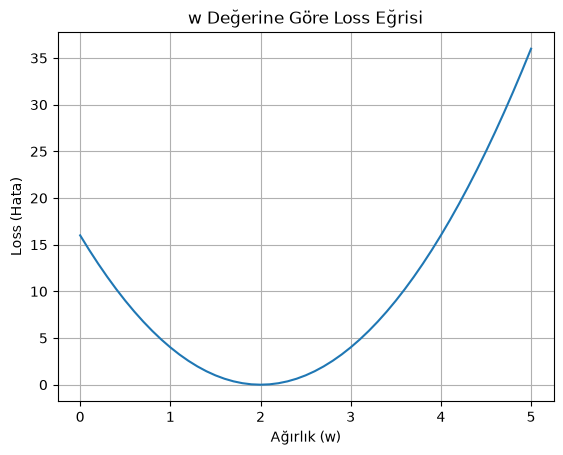

In [46]:
import matplotlib.pyplot as plt

plt.plot(w_history, loss_history)
plt.xlabel("Ağırlık (w)")
plt.ylabel("Loss (Hata)")
plt.title("w Değerine Göre Loss Eğrisi")
plt.grid(True)
plt.show()

Görev 5:

Grafik ile beraber mimimum noktanın w = 2.0 olduğunu gördük. Ama gerçek modeller bu şekilde hepsini denemez tüm ihtimallerin. Bunun yerine türev ile değeri buluruz.

Şu şekilde:
1. rastgele bir w ile başlarız. 
2. o anki hatayı hesapla: los_function(y,w.x)
3. w'yi biraz kaydırırız: h=0.00001 -> w + h
4. yeni loss'u hesaplarız: loss_function(y,(w+h).x)
5. türevi bul: grad = (L2 - L1)/h
6. ağırlığı eğimin tersi yönünde güncelleriz: w = w - (learnin_rate x grad)
7. minimumu bulana kadar devam ederiz.


In [44]:
w = 5.0
h = 0.00001
learning_rate = 0.1

for i in range(100):
    L1 = loss_function(y, w * x)
    L2 = loss_function(y, (w + h) * x)

    #türev
    grad = (L2 - L1) / h
    
    # Parametre güncelleme
    w = w - learning_rate * grad
    
    print(f"Adım {i+1} | w: {w:.4f} | Loss: {L1:.6f} | Grad: {grad:.4f}")
    
    if abs(grad) < 0.00001:
        break

Adım 1 | w: 2.6000 | Loss: 36.000000 | Grad: 24.0000
Adım 2 | w: 2.1200 | Loss: 1.439981 | Grad: 4.8000
Adım 3 | w: 2.0240 | Loss: 0.057595 | Grad: 0.9600
Adım 4 | w: 2.0048 | Loss: 0.002303 | Grad: 0.1920
Adım 5 | w: 2.0010 | Loss: 0.000092 | Grad: 0.0384
Adım 6 | w: 2.0002 | Loss: 0.000004 | Grad: 0.0077
Adım 7 | w: 2.0000 | Loss: 0.000000 | Grad: 0.0015
Adım 8 | w: 2.0000 | Loss: 0.000000 | Grad: 0.0003
Adım 9 | w: 2.0000 | Loss: 0.000000 | Grad: 0.0001
Adım 10 | w: 2.0000 | Loss: 0.000000 | Grad: 0.0000
Adım 11 | w: 2.0000 | Loss: 0.000000 | Grad: 0.0000
